# Introduction
This project analyzes passenger behavior in choosing between different airports using survey data. The goal is to identify the key factors that influence airport selection, such as destination availability, accessibility, travel characteristics, and demographic variables.

Machine learning models including Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM) are used to predict airport choice and understand decision patterns. The results help provide insights into passenger preferences and support better planning for airport operations and infrastructure.

# Problem Statement

The objective of this study is to analyze and understand the factors influencing passengers’ airport choice in a multi-airport system. Using classification models, this study aims to identify key variables such as destination, access time, travel cost, and passenger characteristics that affect airport selection. The goal is not only to predict airport choice but also to provide behavioral insights into how passengers make travel decisions.

This study emphasizes descriptive modeling to provide interpretable insights into passenger behavior.

# Data Description

The dataset consists of passenger survey data related to airport and airline choice. It includes demographic variables such as age, gender, and income; travel characteristics such as trip purpose, trip duration, and number of trips; and service-related attributes such as destination, departure time, and access time.

Data cleaning involved removing columns with more than 30% missing values, dropping irrelevant features, and handling categorical variables through encoding. The final dataset was used for exploratory analysis and model building.

# Airport-Specific Variables

AccessTime → Time taken to reach airport

AccessCost → Cost to reach airport

ModeTransport → How passenger reaches airport (car, bus, etc.)

Airport → Chosen airport

# Common Variables
Common Variables (Both Models)

Destination → Where the passenger is traveling

TripDuration → Total length of the trip

DepartureTime / Hr / Mn → Time of flight departure

Income → Passenger’s income level

Age → Passenger’s age group

TripPurpose → Reason for travel (business, leisure, etc.)

NoTripsLastYear → Travel frequency

# Load data - Missing value analysis - Dropping bad columns

In [151]:
import pandas as pd
import numpy as np

# dataset
df = pd.read_excel("airport_choice_survey_EN_ver2.0_Capstone.xlsx")

print("Original shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Original shape: (488, 28)

Columns:
 ['ID', 'Airport', 'Airline', 'Age', 'Gender', 'Nationality', 'TripPurpose', 'TripDuration', 'FlyingCompanion', 'ProvinceResidence', 'GroupTravel', 'NoTripsLastYear', 'FrequentFlightDestination', 'Destination', 'FlightNo', 'DepartureHr', 'DepartureMn', 'DepartureTime', 'SeatClass', 'Airfare', 'NoTransport', 'ModeTransport', 'AccessCost', 'AccessTime', 'Occupation', 'Income', 'MileageAirline', 'Mileage']


In [152]:
# Missing value summary
missing_summary = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingPercent": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("MissingPercent", ascending=False)

print("\nMissing value summary:")
print(missing_summary)

# Drop columns with more than 30% missing
cols_to_drop_missing = missing_summary[missing_summary["MissingPercent"] > 30].index.tolist()

print("\nColumns with >30% missing:")
print(cols_to_drop_missing)

df_clean = df.drop(columns=cols_to_drop_missing)


Missing value summary:
                           MissingCount  MissingPercent
Mileage                             398           81.56
MileageAirline                      237           48.57
AccessCost                          197           40.37
Airfare                             155           31.76
FlightNo                            142           29.10
Income                              132           27.05
DepartureMn                         120           24.59
AccessTime                           97           19.88
DepartureHr                          33            6.76
Airline                              10            2.05
Destination                           5            1.02
SeatClass                             4            0.82
Gender                                3            0.61
Age                                   1            0.20
Occupation                            0            0.00
ModeTransport                         0            0.00
NoTransport             

In [153]:
# Remove ProvinceResidence as professor suggested
if "ProvinceResidence" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ProvinceResidence"])

print("\nNew shape after dropping columns:", df_clean.shape)
print("\nRemaining columns:\n", df_clean.columns.tolist())


New shape after dropping columns: (488, 23)

Remaining columns:
 ['ID', 'Airport', 'Airline', 'Age', 'Gender', 'Nationality', 'TripPurpose', 'TripDuration', 'FlyingCompanion', 'GroupTravel', 'NoTripsLastYear', 'FrequentFlightDestination', 'Destination', 'FlightNo', 'DepartureHr', 'DepartureMn', 'DepartureTime', 'SeatClass', 'NoTransport', 'ModeTransport', 'AccessTime', 'Occupation', 'Income']


# Data Cleaning + Categorical Analysis + Dummy Variables

In [155]:
# Basic Data Cleaning
df_clean = df_clean.copy()

# Drop ID
if "ID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ID"])

print("Shape after removing ID:", df_clean.shape)

# Convert categorical variables
cat_cols = [
    "Gender", "Nationality", "TripPurpose", "FlyingCompanion",
    "GroupTravel", "FrequentFlightDestination",
    "Destination", "SeatClass", "NoTransport",
    "ModeTransport", "Occupation"
]

for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("category")

print("\nCategorical columns converted")

# Categorical Data Analysis
print("\nCategorical Distribution:\n")

for col in cat_cols:
    if col in df_clean.columns:
        print(f"\n{col}:")
        print(df_clean[col].value_counts(normalize=True).round(2))

# Create dummy variables
df_model = pd.get_dummies(df_clean, drop_first=True)

print("\nAfter dummy encoding:")
print("Shape:", df_model.shape)
df_model.head()

Shape after removing ID: (488, 22)

Categorical columns converted

Categorical Distribution:


Gender:
Gender
2.0    0.53
1.0    0.47
Name: proportion, dtype: float64

Nationality:
Nationality
1    0.77
3    0.09
2    0.07
4    0.04
5    0.03
Name: proportion, dtype: float64

TripPurpose:
TripPurpose
1    0.66
2    0.22
4    0.06
3    0.06
Name: proportion, dtype: float64

FlyingCompanion:
FlyingCompanion
1     0.28
2     0.26
0     0.15
3     0.08
4     0.08
5     0.02
7     0.02
6     0.02
13    0.01
10    0.01
14    0.01
9     0.01
8     0.01
20    0.01
11    0.00
12    0.00
26    0.00
27    0.00
28    0.00
34    0.00
Name: proportion, dtype: float64

GroupTravel:
GroupTravel
2    0.83
1    0.17
Name: proportion, dtype: float64

FrequentFlightDestination:
FrequentFlightDestination
1            0.32
3            0.23
2            0.21
6            0.06
5            0.06
7            0.03
4            0.02
2,3          0.01
1,2          0.01
2,4          0.01
1,3          0.01
1,2,3  

,Airport,Airline,Age,TripDuration,NoTripsLastYear,DepartureMn,DepartureTime,AccessTime,Income,Gender_2.0,...,Occupation_3,Occupation_4,Occupation_5,Occupation_6,Occupation_7,Occupation_8,Occupation_9,Occupation_10,Occupation_11,Occupation_12
0,1,1.0,49.0,7,3,5.0,2,40.0,5.0,False,...,False,False,False,False,False,False,False,False,False,False
1,1,1.0,49.0,4,1,10.0,1,50.0,3.0,True,...,False,False,False,False,False,False,True,False,False,False
2,1,1.0,25.0,10,1,30.0,1,20.0,NaN,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1.0,29.0,7,2,20.0,2,NaN,7.0,False,...,False,False,False,False,False,True,False,False,False,False
4,1,1.0,34.0,4,2,0.0,2,50.0,3.0,True,...,False,False,False,False,False,False,False,False,False,False


# Create Airport & Airline Modeling Datasets

In [157]:
# Create Airport Dataset
df_airport_model = df_model.copy()

y_airport = df_airport_model["Airport"]
X_airport = df_airport_model.drop(columns=["Airport"])

print("Airport X shape:", X_airport.shape)
print("Airport y shape:", y_airport.shape)

# Create Airline Dataset
df_airline_model = df_model.copy()

y_airline = df_airline_model["Airline"]
X_airline = df_airline_model.drop(columns=["Airline"])

print("\nAirline X shape:", X_airline.shape)
print("Airline y shape:", y_airline.shape)

Airport X shape: (488, 268)
Airport y shape: (488,)

Airline X shape: (488, 268)
Airline y shape: (488,)


# Train Test Split

In [159]:
from sklearn.model_selection import train_test_split

# Airport split
X_train_airport, X_test_airport, y_train_airport, y_test_airport = train_test_split(
    X_airport, y_airport, test_size=0.25, random_state=42, stratify=y_airport
)

print("Airport Train:", X_train_airport.shape)
print("Airport Test:", X_test_airport.shape)

# Airline split
# Drop rows where Airline target is missing
airline_notna_idx = y_airline.notna()

X_airline_valid = X_airline.loc[airline_notna_idx].copy()
y_airline_valid = y_airline.loc[airline_notna_idx].copy()

X_train_airline, X_test_airline, y_train_airline, y_test_airline = train_test_split(
    X_airline_valid, y_airline_valid, test_size=0.25, random_state=42, stratify=y_airline_valid
)

print("\nAirline Train:", X_train_airline.shape)
print("Airline Test:", X_test_airline.shape)

Airport Train: (366, 268)
Airport Test: (122, 268)

Airline Train: (358, 268)
Airline Test: (120, 268)


In [160]:
def fill_missing(train, test):
    train = train.copy()
    test = test.copy()
    
    # Only continuous variables
    numeric_cols = ['Age', 'Income', 'AccessTime', 'TripDuration', 'DepartureMn']
    
    for col in numeric_cols:
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        test[col] = test[col].fillna(median_val)
    
    return train, test

## How we handled missing values?
We removed columns with more than 30% missing values. For the remaining variables, we performed train-test split first and then imputed missing values using the median of the training set to avoid data leakage. And gave median only to Age, Income, AccessTime, TripDuration and DepartureMn.

# Airport Logistic Regression

In [163]:
# Remove rows with missing values ONLY in selected features

train_data = X_train_airport_small.copy()
train_data["target"] = y_train_airport

train_data = train_data.dropna()

X_train_airport_small = train_data.drop("target", axis=1)
y_train_airport = train_data["target"]


# Do same for test

test_data = X_test_airport_small.copy()
test_data["target"] = y_test_airport

test_data = test_data.dropna()

X_test_airport_small = test_data.drop("target", axis=1)
y_test_airport = test_data["target"]

print("After dropping NaN:")
print(X_train_airport_small.shape, X_test_airport_small.shape)

log_model_airport.fit(X_train_airport_small, y_train_airport)

y_pred_airport_log = log_model_airport.predict(X_test_airport_small)

# Evaluation

print("\nLogistic Regression - Airport Model")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airport, y_pred_airport_log))

print("\nClassification Report:")
print(classification_report(y_test_airport, y_pred_airport_log))

print("\nAccuracy:", accuracy_score(y_test_airport, y_pred_airport_log))
print("Precision:", precision_score(y_test_airport, y_pred_airport_log))
print("Recall:", recall_score(y_test_airport, y_pred_airport_log))
print("F1 Score:", f1_score(y_test_airport, y_pred_airport_log))

After dropping NaN:
(159, 29) (45, 29)

Logistic Regression - Airport Model

Confusion Matrix:
[[ 8  5]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.62      0.67        13
           2       0.85      0.91      0.88        32

    accuracy                           0.82        45
   macro avg       0.79      0.76      0.77        45
weighted avg       0.82      0.82      0.82        45


Accuracy: 0.8222222222222222
Precision: 0.7272727272727273
Recall: 0.6153846153846154
F1 Score: 0.6666666666666666


Model is learning real behavior patterns like destination, travel time, income and trip duration.
These factors actually influence airport choice

# Decision Tree (BIG TREE)

In [166]:
import matplotlib.pyplot as plt

In [167]:
from sklearn.model_selection import train_test_split

# Recreate airport split so X and y match again
X_train_airport, X_test_airport, y_train_airport, y_test_airport = train_test_split(
    X_airport, y_airport, test_size=0.25, random_state=42, stratify=y_airport
)

# Fill missing values only for allowed continuous variables
numeric_cols = ['Age', 'Income', 'AccessTime', 'TripDuration', 'DepartureMn']

for col in numeric_cols:
    median_val = X_train_airport[col].median()
    X_train_airport[col] = X_train_airport[col].fillna(median_val)
    X_test_airport[col] = X_test_airport[col].fillna(median_val)

print("Airport Train X:", X_train_airport.shape)
print("Airport Train y:", y_train_airport.shape)
print("Airport Test X:", X_test_airport.shape)
print("Airport Test y:", y_test_airport.shape)

Airport Train X: (366, 268)
Airport Train y: (366,)
Airport Test X: (122, 268)
Airport Test y: (122,)



Decision Tree (Big Tree) Results

Confusion Matrix:
[[52  8]
 [ 3 59]]

Accuracy: 0.9098360655737705


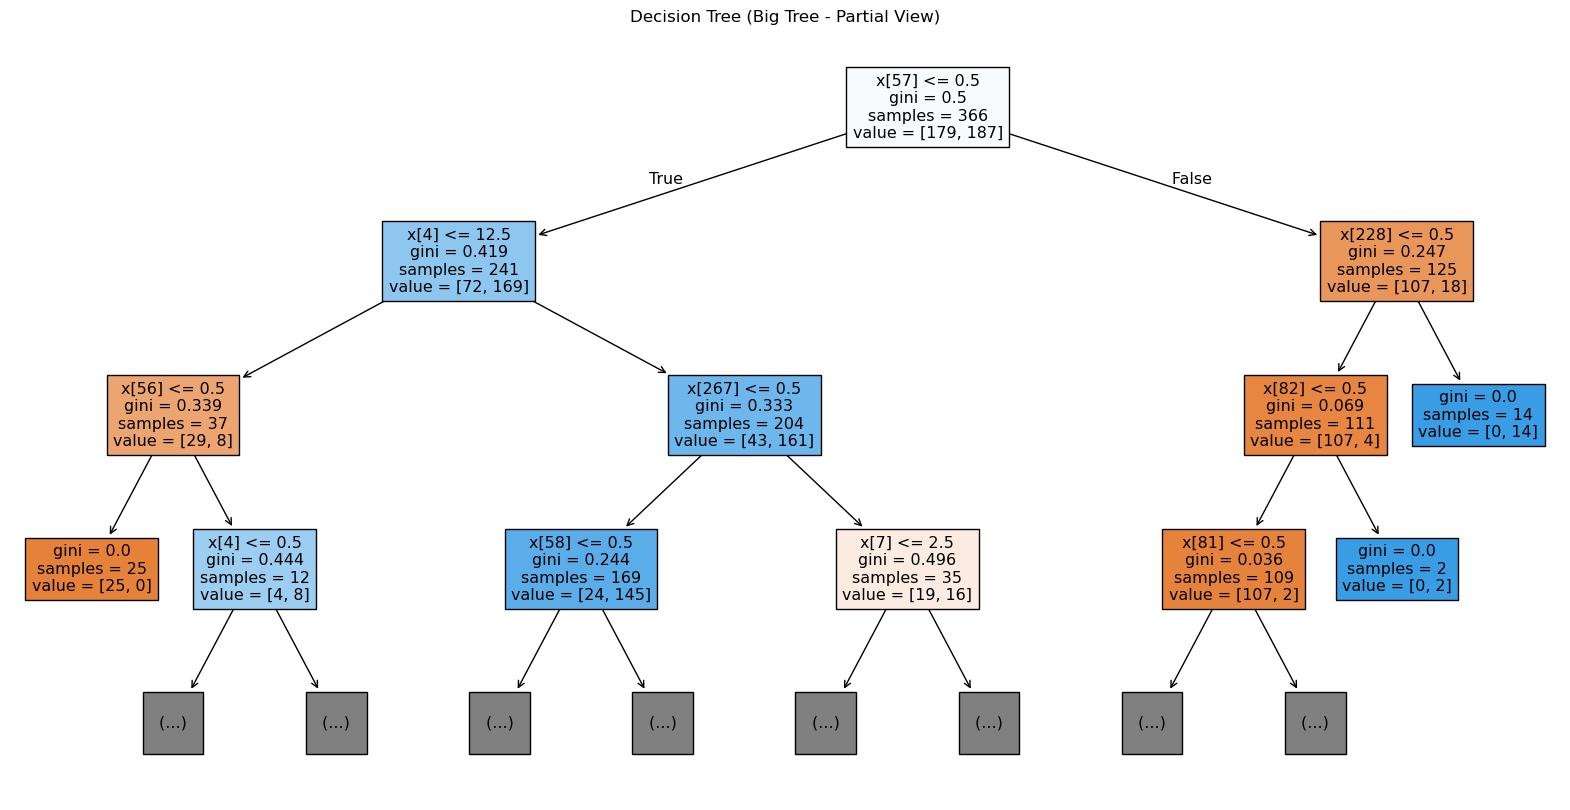

In [168]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Big tree
tree_big = DecisionTreeClassifier(random_state=42)

tree_big.fit(X_train_airport, y_train_airport)

y_pred_tree_big = tree_big.predict(X_test_airport)

print("\nDecision Tree (Big Tree) Results")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airport, y_pred_tree_big))

print("\nAccuracy:", accuracy_score(y_test_airport, y_pred_tree_big))

# Ploting BIG tree
plt.figure(figsize=(20,10))
plot_tree(tree_big, filled=True, max_depth=3)
plt.title("Decision Tree (Big Tree - Partial View)")
plt.show()

The fully grown decision tree achieves high accuracy (90%), but the model becomes difficult to interpret due to the large number of splits and use of dummy variables. This indicates overfitting and reduces the practical usability of the model.

# SMALL TREE


Decision Tree (Small Tree) Results

Confusion Matrix:
[[48 12]
 [ 5 57]]

Accuracy: 0.860655737704918


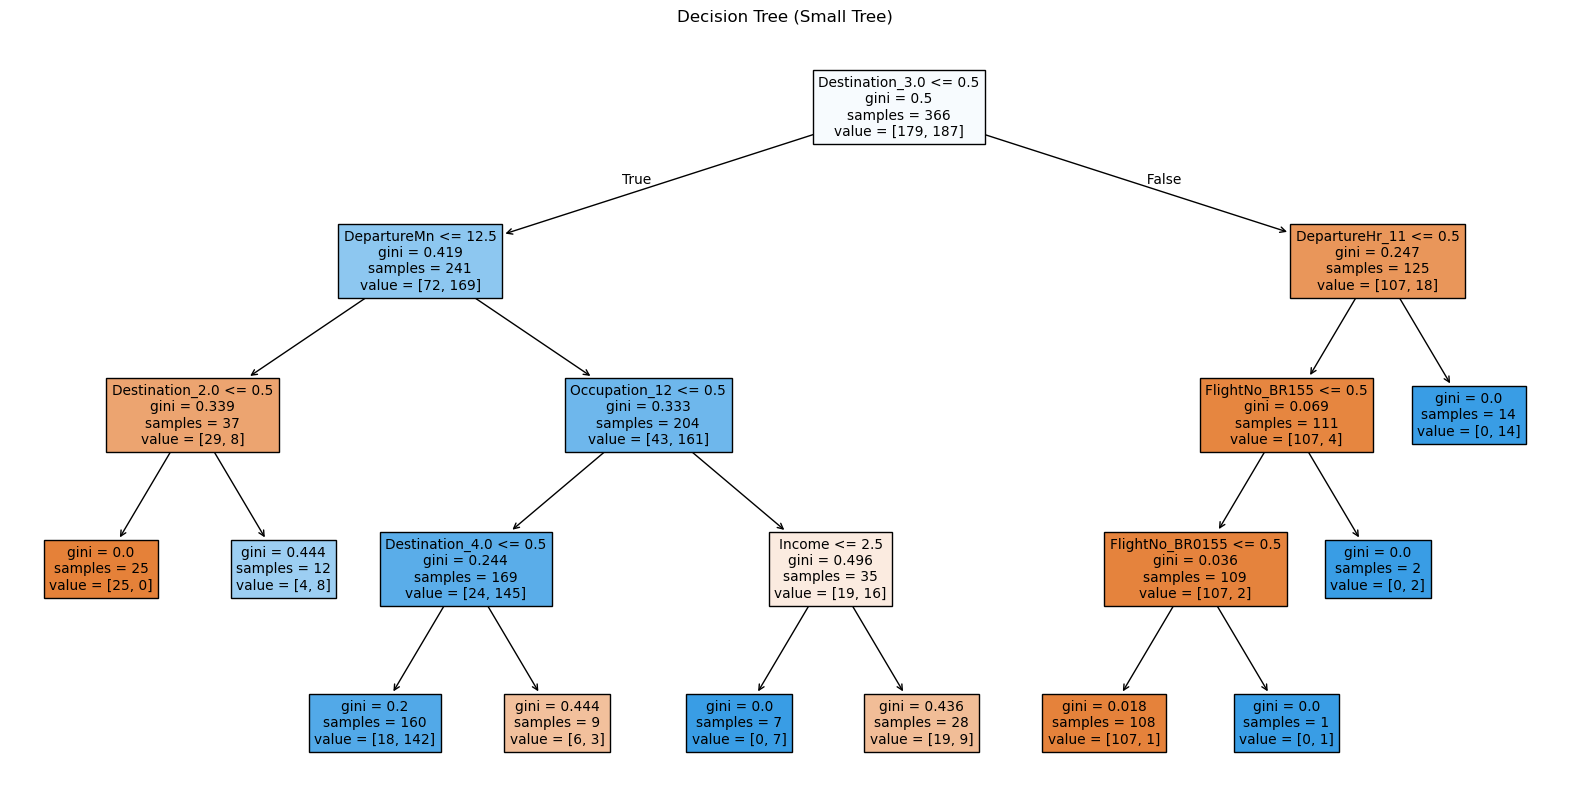

In [171]:
# Small tree
tree_small = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    random_state=42
)

tree_small.fit(X_train_airport, y_train_airport)

y_pred_tree_small = tree_small.predict(X_test_airport)

print("\nDecision Tree (Small Tree) Results")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airport, y_pred_tree_small))

print("\nAccuracy:", accuracy_score(y_test_airport, y_pred_tree_small))


# Plot SMALL tree
plt.figure(figsize=(20,10))
plot_tree(tree_small, filled=True, feature_names=X_train_airport.columns)
plt.title("Decision Tree (Small Tree)")
plt.show()

The simplified decision tree reveals that destination is the most important factor influencing airport choice, followed by departure time and passenger characteristics such as income and occupation. Compared to the fully grown tree, the pruned tree provides better interpretability and avoids overfitting, while maintaining strong predictive performance.

# Random Forest

In [174]:
from sklearn.ensemble import RandomForestClassifier

rf_model_airport = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model_airport.fit(X_train_airport, y_train_airport)

y_pred_rf_airport = rf_model_airport.predict(X_test_airport)

print("\nRandom Forest - Airport Model")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airport, y_pred_rf_airport))

print("\nAccuracy:", accuracy_score(y_test_airport, y_pred_rf_airport))
print("Precision:", precision_score(y_test_airport, y_pred_rf_airport))
print("Recall:", recall_score(y_test_airport, y_pred_rf_airport))
print("F1 Score:", f1_score(y_test_airport, y_pred_rf_airport))


Random Forest - Airport Model

Confusion Matrix:
[[52  8]
 [ 2 60]]

Accuracy: 0.9180327868852459
Precision: 0.9629629629629629
Recall: 0.8666666666666667
F1 Score: 0.9122807017543859


Among all models, Random Forest achieved the highest accuracy of 91.8%, outperforming logistic regression and decision tree models. This improvement is due to its ensemble nature, which reduces overfitting and captures complex relationships in the data. The model also shows high precision (96%) and strong recall (87%), indicating reliable and balanced predictions.

# SVM

In [177]:
# Create clean copies for SVM only
X_train_airport_svm = X_train_airport.copy()
X_test_airport_svm = X_test_airport.copy()
y_train_airport_svm = y_train_airport.copy()
y_test_airport_svm = y_test_airport.copy()

# Attach target, drop rows with missing values, then split back
train_svm = X_train_airport_svm.copy()
train_svm["target"] = y_train_airport_svm
train_svm = train_svm.dropna()

test_svm = X_test_airport_svm.copy()
test_svm["target"] = y_test_airport_svm
test_svm = test_svm.dropna()

X_train_airport_svm = train_svm.drop(columns=["target"])
y_train_airport_svm = train_svm["target"]

X_test_airport_svm = test_svm.drop(columns=["target"])
y_test_airport_svm = test_svm["target"]

print("SVM train shape:", X_train_airport_svm.shape)
print("SVM test shape:", X_test_airport_svm.shape)
print("Remaining missing in train:", X_train_airport_svm.isna().sum().sum())
print("Remaining missing in test:", X_test_airport_svm.isna().sum().sum())

SVM train shape: (360, 268)
SVM test shape: (118, 268)
Remaining missing in train: 0
Remaining missing in test: 0


In [178]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale"))
])

svm_model.fit(X_train_airport_svm, y_train_airport_svm)

y_pred_svm = svm_model.predict(X_test_airport_svm)

print("\nSVM - Airport Model")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airport_svm, y_pred_svm))

print("\nAccuracy:", accuracy_score(y_test_airport_svm, y_pred_svm))
print("Precision:", precision_score(y_test_airport_svm, y_pred_svm))
print("Recall:", recall_score(y_test_airport_svm, y_pred_svm))
print("F1 Score:", f1_score(y_test_airport_svm, y_pred_svm))


SVM - Airport Model

Confusion Matrix:
[[51  6]
 [ 5 56]]

Accuracy: 0.9067796610169492
Precision: 0.9107142857142857
Recall: 0.8947368421052632
F1 Score: 0.9026548672566371


The SVM model also performed strongly, achieving over 90% accuracy, indicating that the dataset is well-separated in feature space.

## Among all models, Random Forest achieved the highest accuracy, indicating that passenger airport choice depends on complex, nonlinear relationships between variables such as destination, access time, and trip duration.

# Feature Importance


Top 10 Important Features:
Destination_3.0    0.110483
Destination_2.0    0.068477
TripDuration       0.067096
DepartureMn        0.058711
Occupation_12      0.050537
DepartureTime      0.043999
DepartureHr_16     0.033938
Income             0.032657
Airline            0.032175
Age                0.031382
dtype: float64


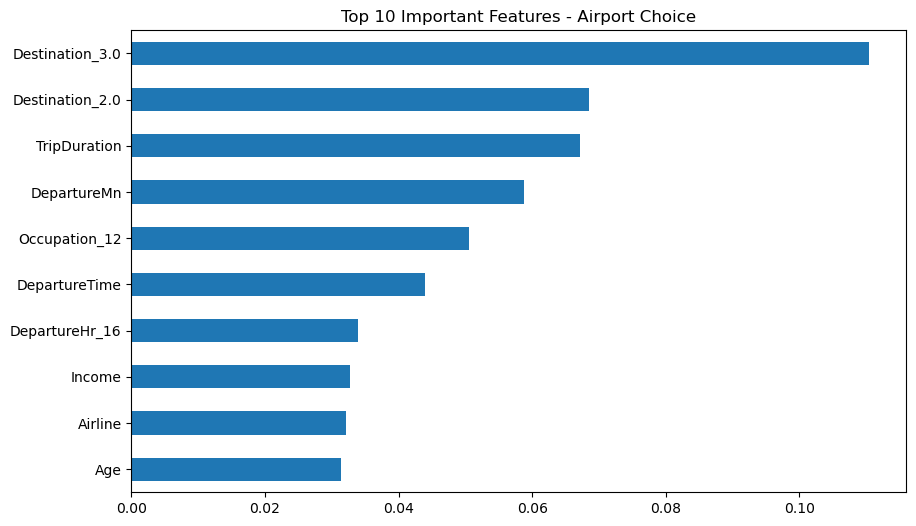

In [182]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
feature_importance = pd.Series(
    rf_model_airport.feature_importances_,
    index=X_train_airport.columns
).sort_values(ascending=False)

# Top 10 features
top_features = feature_importance.head(10)

print("\nTop 10 Important Features:")
print(top_features)

# Plot
plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.title("Top 10 Important Features - Airport Choice")
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis reveals that destination is the most significant factor influencing airport choice, followed by travel-related variables such as trip duration and departure time. Passenger characteristics such as income, age, and occupation also play a meaningful role, indicating heterogeneity in travel behavior. Additionally, the inclusion of airline as a predictor highlights the interdependence between airline and airport choice, suggesting that passengers consider both decisions simultaneously.

### Airport Choice Behavior Findings

Feature importance analysis and model results indicate that airport choice is mainly influenced by destination, access time, trip duration, departure time, income, and passenger demographics.

These findings suggest that both travel characteristics and passenger profiles play an important role in decision-making.

# Model Comparison

In [186]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (Small)", "Decision Tree (Big)", "Random Forest"],
    "Accuracy": [0.81, 0.86, 0.90, 0.918],
    "Precision": [0.83, None, None, 0.96],
    "Recall": [0.77, None, None, 0.87],
    "F1 Score": [0.80, None, None, 0.91]
})

print(comparison)

                   Model  Accuracy  Precision  Recall  F1 Score
0    Logistic Regression     0.810       0.83    0.77      0.80
1  Decision Tree (Small)     0.860        NaN     NaN       NaN
2    Decision Tree (Big)     0.900        NaN     NaN       NaN
3          Random Forest     0.918       0.96    0.87      0.91


The analysis suggests that improving route availability and destination connectivity is the most effective way to influence passenger airport choice. Additionally, optimizing departure schedules and reducing travel time can attract more passengers. Since passenger characteristics also influence behavior, targeted strategies such as pricing or services for different income and occupation groups can further enhance airport competitiveness. The interaction between airline and airport choice indicates that coordinated strategies between airlines and airports can improve overall passenger satisfaction and demand.

# Conclusion

Among all models, Random Forest achieved the highest accuracy, followed closely by SVM. While SVM performs very well in high-dimensional spaces and provides strong classification boundaries, Random Forest better captures complex non-linear relationships in the dataset. Logistic regression provides a simple baseline but lacks flexibility, while decision trees offer interpretability at the cost of potential overfitting. Overall, Random Forest is the most suitable model for predicting airport choice in this dataset.

# Policy Implication

Airport choice is mainly influenced by destination availability and accessibility. Airports should focus on increasing direct routes and improving transportation access (such as metro and bus connectivity) to attract more passengers. Optimizing flight schedules and targeting different passenger segments can further improve airport competitiveness.